In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initialise vars

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/new'

In [5]:
news_merged_filepath = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/merged_data_news_comments.csv'
nonnews_merged_filepath = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/merged_data_nonnews_comments.csv'

In [6]:
news_df = pd.read_csv(news_merged_filepath)
nonnews_df = pd.read_csv(nonnews_merged_filepath) 

In [7]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [8]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [9]:
news_df.shape, nonnews_df.shape

((1279, 14), (1367, 14))

In [10]:
news_df.drop(columns=['caption'], inplace=True)
nonnews_df.drop(columns=['caption'], inplace=True)

In [11]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(330)

In [12]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [13]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [14]:
news_df.shape, nonnews_df.shape

((980, 13), (1037, 13))

### comment level

In [15]:
news_df = pd.read_csv('/Users/brahmaninutakki/saarland/insta_comments/saved_data/merged_data_news_comments.csv')
news_df.shape

(1279, 13)

In [16]:
news_df.dropna(subset=['caption'], inplace=True)
news_df.shape

(1129, 13)

In [17]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [18]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [19]:
news_df.shape

(830, 14)

In [20]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == ' ':
                news_df.loc[i, col] = f'{(x[0], "empty")}'

In [21]:
for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == 'empty':
                print(x)

('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')


In [22]:
for url in news_df['urlid'].unique().tolist():
    if news_df[news_df['urlid'] == url]['caption_text'].nunique() != 1:
        print(url, news_df[news_df['urlid'] == url]['caption_text'].nunique())

In [23]:
url_caption_map = {}

for url in news_df['urlid'].unique().tolist():
    comments = news_df[news_df['urlid'] == url]['caption_text'].unique()[0]

    url_caption_map[url] = comments

In [24]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

comment_caption_map = {}
for caption in news_df['caption_text'].tolist():
    if caption not in comment_caption_map:
        comment_caption_map[caption] = []
    for col in cols:
        temp = news_df[news_df['caption_text'] == caption][col].tolist()
        comment_caption_map[caption] += temp

    comment_caption_map[caption] = list(set(comment_caption_map[caption]))

In [25]:
count = 0

for k, v in comment_caption_map.items():
    count+=len(v)

count

991

In [26]:
for caption, texts in comment_caption_map.items():
    for text in texts:
        if pd.notna(text):
            x = ast.literal_eval(text)
            username = x[0]
            comment = x[1]

In [27]:
labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='gpt annotations no account')
# labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='annotations ideology')
labels_df.shape

(1013, 4)

In [28]:
labels_df['comment'] = labels_df['comment'].fillna('empty')

In [29]:
labels_df.rename(columns={'caption': 'caption_text'}, inplace=True)

In [30]:
url_caption_map_reverse = {v:k for k, v in url_caption_map.items()}
len(url_caption_map_reverse) == len(url_caption_map)

True

In [31]:
for x in url_caption_map_reverse:
    if 'lemme' in x.lower():
        print(x, url_caption_map_reverse[x])

'LEMME SHOW YOU': A police officer in New Mexico turned a quick visit to a basketball court into a highlight, teaching teens the “skyhook,” made famous by NBA legend Kareem Abdul-Jabbar, and sinking an unbelievable trick shot. DRYXH9GlIcS


In [32]:
labels_df['urlid'] = labels_df['caption_text'].apply(lambda x: url_caption_map_reverse[x] if x in url_caption_map_reverse else 'DRYXH9GlIcS')
labels_df[labels_df['urlid'] == 'DRYXH9GlIcS']

,username,caption_text,comment,label,urlid
412,jayce_united,LEMME SHOW YOU': A police officer in New Mexic...,Police officer ballin 🏀 👮,Supportive,DRYXH9GlIcS
413,oceandm514,LEMME SHOW YOU': A police officer in New Mexic...,"Good officer, the kids won’t forget❤️",Supportive,DRYXH9GlIcS
414,hawk.4532998,LEMME SHOW YOU': A police officer in New Mexic...,It's great that traffic officers take a little...,Supportive,DRYXH9GlIcS
415,zachbreeden1,LEMME SHOW YOU': A police officer in New Mexic...,That's a cool cop right there,Supportive,DRYXH9GlIcS
416,rylee.xmas,LEMME SHOW YOU': A police officer in New Mexic...,See police are cool its a certain group of peo...,Supportive,DRYXH9GlIcS
417,brandon.reflects,LEMME SHOW YOU': A police officer in New Mexic...,We have a code 6-7. Do you copy?,Neutral,DRYXH9GlIcS
418,yourdistractions,LEMME SHOW YOU': A police officer in New Mexic...,Good interactions with teens is what more poli...,Supportive,DRYXH9GlIcS
419,aldominguez17,LEMME SHOW YOU': A police officer in New Mexic...,It's easier to be kind,Supportive,DRYXH9GlIcS
420,chasevanarman24,LEMME SHOW YOU': A police officer in New Mexic...,That’s how u serve and protect the communityyyyy,Supportive,DRYXH9GlIcS
421,corey01852,LEMME SHOW YOU': A police officer in New Mexic...,Why he sound like Johnny hamcheck,Neutral,DRYXH9GlIcS


In [33]:
labels_df['comment_combined'] = labels_df.apply(lambda x: (x['username'], x['comment']), axis=1)
labels_df

,username,caption_text,comment,label,urlid,comment_combined
0,terp00,Speaking to Editor-in-Chief Alex Marlow @marlo...,Maga died when trump went Israel first over Am...,Against,DRWBiQXDG0H,"(terp00, Maga died when trump went Israel firs..."
1,alton_klompus,Speaking to Editor-in-Chief Alex Marlow @marlo...,@wearebreitbart slowly distancing themselves f...,Supportive,DRWBiQXDG0H,"(alton_klompus, @wearebreitbart slowly distanc..."
2,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,AMERICA FIRST !! ONLY !! THE CORPORATE RINOS M...,Supportive,DRWBiQXDG0H,"(i_tr00per, AMERICA FIRST !! ONLY !! THE CORPO..."
3,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,WE ARE NOT COMING TOGETHER UNTIL THE GOP BECOM...,Against,DRWBiQXDG0H,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T..."
4,loretta.bauer.35,Speaking to Editor-in-Chief Alex Marlow @marlo...,I thought that was exactly why we voted for Tr...,Supportive,DRWBiQXDG0H,"(loretta.bauer.35, I thought that was exactly ..."
...,...,...,...,...,...,...
1008,return_of__the_mack,In an era defined by major political divisions...,Ban lobbying and politics will change,Supportive,DRYMvrrFks8,"(return_of__the_mack, Ban lobbying and politic..."
1009,gwyneddstuart,In an era defined by major political divisions...,The call is coming from inside the building,Against,DRYMvrrFks8,"(gwyneddstuart, The call is coming from inside..."
1010,brianmpalmieri,In an era defined by major political divisions...,We need to take back at least half of their co...,Against,DRYMvrrFks8,"(brianmpalmieri, We need to take back at least..."
1011,jim.emerick.9,In an era defined by major political divisions...,They are 50% of maga donors...,Neutral,DRYMvrrFks8,"(jim.emerick.9, They are 50% of maga donors...)"


In [34]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    news_df[f'{col}_label'] = news_df[col].apply(lambda x: labels_df[labels_df['comment_combined'] == ast.literal_eval(x)]['label'].values[0] if pd.notna(x) else None)

In [35]:
for col in cols:
    print(news_df[f'{col}_label'].isna().sum(), col, news_df[f'{col}'].isna().sum())

30 male_dem_ny_1_comment 30
9 male_dem_texas_1_comment 9
0 male_rep_ny_1_comment 0
51 male_rep_texas_1_comment 51
9 female_dem_ny_1_comment 9
10 female_dem_texas_1_comment 10
12 female_rep_ny_1_comment 12
11 female_rep_texas_1_comment 11


In [36]:
news_df.shape

(830, 22)

In [37]:
reg_df = get_df_for_regression_comments(news_df, all_crawls, labels_df)

In [38]:
reg_df.drop_duplicates(inplace=True)
reg_df.shape

(24210, 12)

In [39]:
reg_df['presence_no_rank'].value_counts()

presence_no_rank
Yes    20896
No      3314
Name: count, dtype: int64

In [40]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_df['urlid'].nunique()

reg_df = pd.merge(reg_df, posts_data, on='urlid', how='inner')
reg_df.drop(columns=['Url'], inplace=True)
reg_df.drop(columns=['Brahmani_Topics', 'Divya_Topics', 'Hamayoon_Topics'], inplace=True)
reg_df.shape

(24210, 13)

In [41]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(24210, 19)

In [42]:
with open('/Users/brahmaninutakki/saarland/insta_comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_df =reg_df.merge(comments_df, on='urlid', how='left')
reg_df =reg_df.merge(likes_df, on='urlid', how='left')

reg_df[reg_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX7mPtkhbo',
       'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z', 'DRK7-xAEaGg',
       'DRNAF39ESYr', 'DRNI1TVEZ90', 'DRNOKZMkZv9', 'DRVZKhOkeKw',
       'DRV4-1ck1EG', 'DRXO1Q9Co1Y', 'DRX71AeCgTh', 'DRYGzcyEsGL'],
      dtype=object)

In [43]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='urlid', how='outer')
reg_df.shape

(24210, 22)

In [44]:
reg_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,16386.000000,7824.000000
mean,841.307030,1709.247699
std,2101.013304,2702.773218
min,14.000000,17.000000
25%,89.000000,119.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [45]:
reg_df['comments_count'] = reg_df["comments_count"].fillna(reg_df["comments_mising"])
reg_df[['comments_count', 'comments_mising']].describe()
reg_df.drop(columns=['comments_mising'], inplace=True)

In [46]:
reg_df['political_ideology'] = reg_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_df['political_ideology'].value_counts()

political_ideology
Left      10377
Right      8648
Center     5185
Name: count, dtype: int64

In [47]:
reg_df['gender_diff'] = reg_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_df['location_diff'] = reg_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_df['ideology_diff'] = reg_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [48]:
reg_df['presence_no_rank'] = reg_df['presence_no_rank'].map({'Yes': 0, 'No': 1})

In [49]:
reg_nonnews_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/reg_comments_nonnews.xlsx')

In [50]:
reg_df['type'] = 'News'
reg_nonnews_df['type'] = 'Non-News'

In [51]:
concat_df = pd.concat([reg_df, reg_nonnews_df], ignore_index=True)
concat_df.shape

(47943, 26)

#### only news

In [52]:
# for col in ["posts", "followers", "following", "comments_count"]:
#     new_col = col + "_logz"
#     x = np.log1p(reg_df[col].astype(float))
#     reg_df[new_col] = (x - x.mean()) / x.std()

# reg_df["gender"] = pd.Categorical(
#     reg_df["gender"],
#     categories=["female_female", "male_male", "female_male"],
#     ordered=True
# )

# reg_df["ideology"] = pd.Categorical(
#     reg_df["ideology"],
#     categories=["dem_dem", "rep_rep", "dem_rep"],
#     ordered=True
# )

# reg_df["location"] = pd.Categorical(
#     reg_df["location"],
#     categories=["ny_ny", "texas_texas", "ny_texas"],
#     ordered=True
# )

# reg_df['main_topic'] = pd.Categorical(
#     reg_df['main_topic'],
#     categories=['Political', 'Non-Political'],
#     ordered=True
# )

# reg_df["gender_diff"] = pd.Categorical(
#     reg_df["gender_diff"],
#     categories=["No", "Yes"],
#     ordered=True
# )

# reg_df["ideology_diff"] = pd.Categorical(
#     reg_df["ideology_diff"],
#     categories=["No", "Yes"],
#     ordered=True
# )

# reg_df["location_diff"] = pd.Categorical(
#     reg_df["location_diff"],
#     categories=["No", "Yes"],
#     ordered=True
# )

# # reg_df['presence_no_rank'] = pd.Categorical(
# #     reg_df["presence_no_rank"],
# #     categories=["No", "Yes"],
# #     ordered=True
# # )

# reg_df['label'] = pd.Categorical(
#     reg_df["label"],
#     # categories=["Right leaning", "Neutral", "Left leaning"],
#     categories=["Against", "Supportive", "Neutral"],
#     ordered=True
# )

In [53]:
# reg_df['presence_no_rank'].value_counts()

presence_no_rank
0    20896
1     3314
Name: count, dtype: int64

In [54]:
# reg_df['label'].value_counts()

label
Supportive    10049
Against        9027
Neutral        5134
Name: count, dtype: int64

In [55]:
# formula = "presence_no_rank ~ gender_diff + location_diff + ideology_diff + C(label) + C(political_ideology) + C(main_topic) + comments_count_logz"  
# get_vif(formula, reg_df)

,feature,VIF
2,location_diff[T.Yes],1.066611
3,ideology_diff[T.Yes],1.074038
1,gender_diff[T.Yes],1.074545
8,C(main_topic)[T.Non-Political],1.198099
5,C(label)[T.Neutral],1.270463
4,C(label)[T.Supportive],1.282917
9,comments_count_logz,1.356464
7,C(political_ideology)[T.Right],2.040456
6,C(political_ideology)[T.Left],2.146284
0,Intercept,13.788598


In [56]:
# url_pair_counts = (
#     reg_df[['urlid', 'pair_id']]
#     .value_counts()
#     .reset_index(name='count')
# )

# url_pair_counts

# reg_df = pd.merge(reg_df, url_pair_counts, on=['urlid', 'pair_id'], how='outer')
# reg_df['weights'] = 1/reg_df['count']

In [57]:
# news_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(0)

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1580 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-6.770,0.743,-8.185,-5.419,0.009,0.007,6774.0,6589.0,1.0
Location (Binary)[Yes],-0.347,0.068,-0.471,-0.218,0.000,0.001,19225.0,5596.0,1.0
Gender (Binary)[Yes],0.481,0.070,0.351,0.614,0.001,0.001,16377.0,5993.0,1.0
Ideology (Binary)[Yes],0.626,0.070,0.489,0.753,0.001,0.001,15385.0,6327.0,1.0
political_ideology[Left],0.053,0.720,-1.349,1.350,0.007,0.008,9691.0,6131.0,1.0
political_ideology[Right],-0.292,0.734,-1.669,1.108,0.008,0.008,9224.0,5920.0,1.0
label[Supportive],-1.572,0.576,-2.677,-0.515,0.008,0.006,5433.0,5621.0,1.0
label[Neutral],-0.637,0.636,-1.861,0.546,0.009,0.007,5352.0,5375.0,1.0
Comments (log z),1.625,0.409,0.852,2.388,0.005,0.005,5923.0,5601.0,1.0


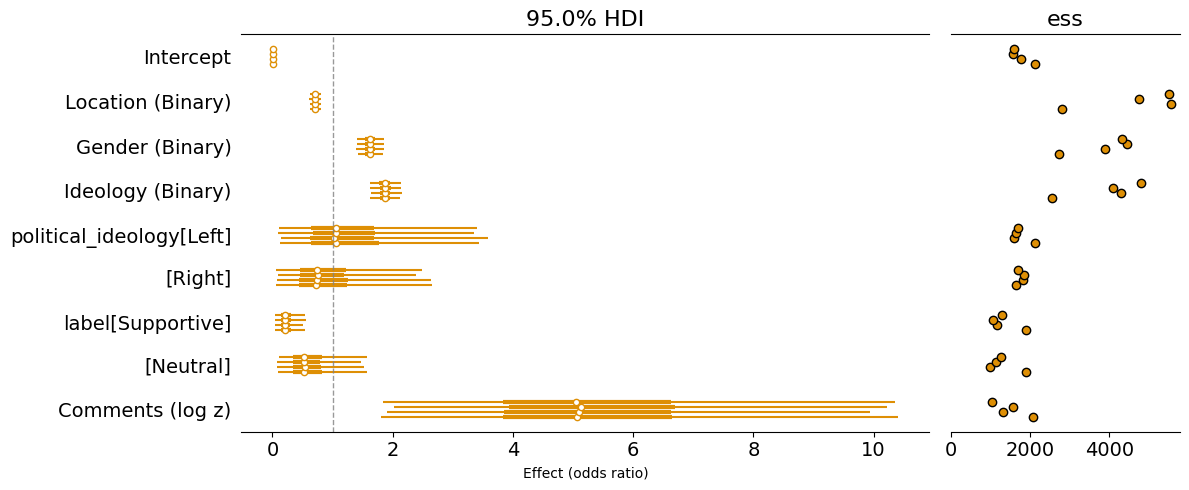

In [58]:
# model = bmb.Model(
#     "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
#     data=reg_df,
#     family="bernoulli",
#     dropna=True,
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=4,
#     random_seed=42,
#     # weights = reg_df['weights'],
#     prob=0.95
# )

# var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'political_ideology', 'label', 'comments_count_logz']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names,
#     colors='C1'
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, account, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1118 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-6.723,0.808,-8.249,-5.247,0.010,0.009,7027.0,5780.0,1.0
location_diff[Yes],-0.347,0.067,-0.476,-0.227,0.000,0.001,19594.0,5568.0,1.0
gender_diff[Yes],0.481,0.069,0.349,0.608,0.001,0.001,18646.0,5713.0,1.0
ideology_diff[Yes],0.625,0.068,0.501,0.755,0.001,0.001,16834.0,6182.0,1.0
label[Supportive],-1.524,0.575,-2.608,-0.454,0.009,0.006,4178.0,5589.0,1.0
label[Neutral],-0.613,0.621,-1.741,0.592,0.009,0.006,4716.0,6092.0,1.0
political_ideology[Left],-0.031,0.777,-1.547,1.356,0.007,0.010,11732.0,5668.0,1.0
political_ideology[Right],-0.076,0.759,-1.556,1.309,0.007,0.009,10859.0,6326.0,1.0
account[cnn],0.129,0.828,-1.336,1.738,0.008,0.010,9747.0,4812.0,1.0
account[forbes],-0.210,0.860,-1.771,1.437,0.007,0.010,13225.0,5753.0,1.0


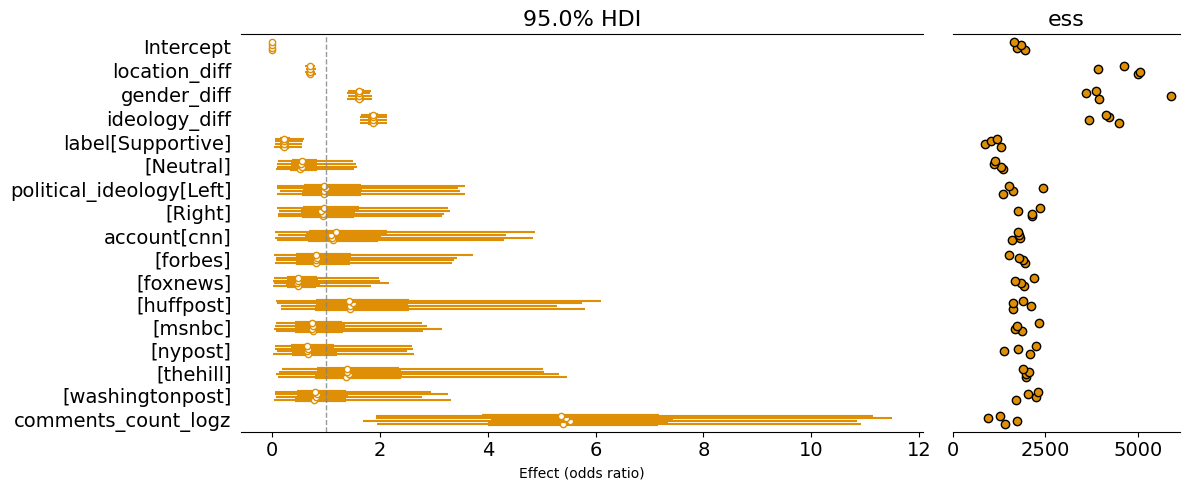

In [58]:
# model = bmb.Model(
#     "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + account + comments_count_logz + (1|urlid) + (1|comment)",
#     data=reg_df,
#     family="bernoulli",
#     dropna=True,
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=4,
#     random_seed=42,
#     # weights = reg_df['weights']
# )

# var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'political_ideology', 'account', 'comments_count_logz']
# display(az.summary(results, var_names=var_names))

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names,
#     colors='C1'
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, location, gender, ideology, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6148 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-7.683,0.750,-9.040,-6.200,0.008,0.008,7830.0,6096.0,1.0
location[texas_texas],0.019,0.099,-0.172,0.199,0.001,0.001,12984.0,5579.0,1.0
location[ny_texas],-0.343,0.084,-0.499,-0.187,0.001,0.001,12935.0,6342.0,1.0
gender[male_male],0.473,0.107,0.269,0.669,0.001,0.001,12667.0,6283.0,1.0
gender[female_male],0.708,0.091,0.540,0.881,0.001,0.001,12202.0,6286.0,1.0
ideology[rep_rep],1.133,0.109,0.928,1.340,0.001,0.001,11806.0,6623.0,1.0
ideology[dem_rep],1.228,0.094,1.061,1.414,0.001,0.001,10950.0,6327.0,1.0
political_ideology[Left],0.070,0.726,-1.278,1.448,0.008,0.008,9103.0,6268.0,1.0
political_ideology[Right],-0.275,0.741,-1.679,1.088,0.007,0.008,10797.0,6175.0,1.0
label[Supportive],-1.552,0.580,-2.677,-0.486,0.007,0.006,6109.0,5509.0,1.0


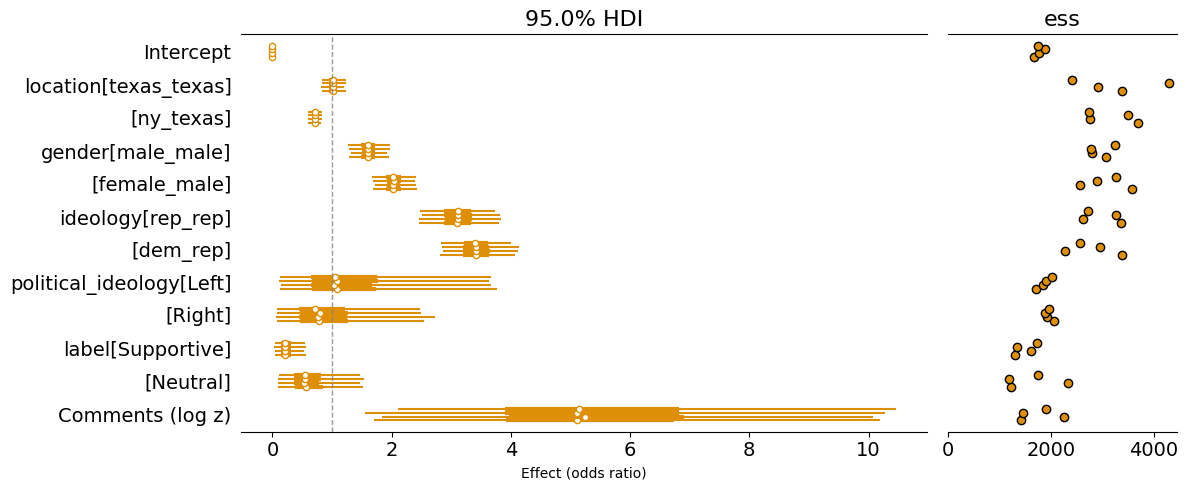

In [59]:
# model = bmb.Model(
#     "presence_no_rank ~ location + gender + ideology + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
#     data=reg_df,
#     family="bernoulli",
#     dropna=True,
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=1,
#     random_seed=42,
#     # weights = reg_df['weights'],
#     prob=0.95
# )

# var_names = ['Intercept', 'location', 'gender', 'ideology', 'political_ideology', 'label', 'comments_count_logz']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names,
#     colors='C1'
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

#### combined

In [52]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(concat_df[col].astype(float))
    concat_df[new_col] = (x - x.mean()) / x.std()

concat_df["gender"] = pd.Categorical(
    concat_df["gender"],
    categories=["male_male", "female_female", "female_male"],
    ordered=True
)

concat_df["ideology"] = pd.Categorical(
    concat_df["ideology"],
    categories=["rep_rep", "dem_dem", "dem_rep"],
    ordered=True
)

concat_df["location"] = pd.Categorical(
    concat_df["location"],
    categories=["texas_texas", "ny_ny", "ny_texas"],
    ordered=True
)

concat_df['type'] = pd.Categorical(
    concat_df['type'],
    categories=['Non-News', 'News'],
    ordered=True
)

concat_df["gender_diff"] = pd.Categorical(
    concat_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

concat_df["ideology_diff"] = pd.Categorical(
    concat_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

concat_df["location_diff"] = pd.Categorical(
    concat_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

# concat_df['presence_no_rank'] = pd.Categorical(
#     concat_df["presence_no_rank"],
#     categories=["No", "Yes"],
#     ordered=True
# )

concat_df['label'] = pd.Categorical(
    concat_df["label"],
    # categories=["Right leaning", "Neutral", "Left leaning"],
    categories=["Against", "Supportive", "Neutral"],
    ordered=True
)

In [53]:
url_pair_counts = (
    concat_df[['urlid', 'pair_id']]
    .value_counts()
    .reset_index(name='count')
)

url_pair_counts

concat_df = pd.merge(concat_df, url_pair_counts, on=['urlid', 'pair_id'], how='outer')
concat_df['weights'] = 1/concat_df['count']

In [54]:
concat_df.shape

(47943, 32)

In [55]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(0)

In [56]:
concat_df

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,gender_diff,location_diff,ideology_diff,type,Unnamed: 0,posts_logz,followers_logz,following_logz,comments_count_logz,count,weights
0,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('agusdermawan', '❤️😍😻')",0.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,229.0,0.111286,0.509229,-3.259564,-0.096458,10.0,0.100000
1,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('the_joannedominique', 'nobody has done their...",0.0,NaN,Neutral,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,230.0,0.111286,0.509229,-3.259564,-0.096458,10.0,0.100000
2,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('stefanosatria1', 'Gym motivation')",0.0,NaN,Neutral,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,231.0,0.111286,0.509229,-3.259564,-0.096458,10.0,0.100000
3,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('daisygizela', '😍😍')",0.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,232.0,0.111286,0.509229,-3.259564,-0.096458,10.0,0.100000
4,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('andrea_regis_motociclistacgpb', 'Tinha uma a...",0.0,NaN,Neutral,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,233.0,0.111286,0.509229,-3.259564,-0.096458,10.0,0.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47938,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('itsriisaaa', 'Lucuuu❤️')",1.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23576.0,0.111286,0.509229,-3.259564,0.556711,13.0,0.076923
47939,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('milenaclavijoj', 'Los gatos son super chismo...",1.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23577.0,0.111286,0.509229,-3.259564,0.556711,13.0,0.076923
47940,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('dwee_yanti', 'Ucilll kepooo deh 😍')",0.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23578.0,0.111286,0.509229,-3.259564,0.556711,13.0,0.076923
47941,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('nurulhasni29', '😍😍😍')",1.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23579.0,0.111286,0.509229,-3.259564,0.556711,13.0,0.076923


In [57]:
formula = "presence_no_rank ~ gender_diff + location_diff + ideology_diff + C(label) + C(type) + comments_count_logz + followers_logz"  
get_vif(formula, concat_df)

,feature,VIF
2,location_diff[T.Yes],1.070719
3,ideology_diff[T.Yes],1.072587
1,gender_diff[T.Yes],1.076347
8,followers_logz,1.161303
6,C(type)[T.News],1.164939
7,comments_count_logz,1.252205
5,C(label)[T.Neutral],1.500888
4,C(label)[T.Supportive],1.530447
0,Intercept,11.717378


In [58]:
# model = bmb.Model(
#     "presence_no_rank ~ location_diff + gender_diff + ideology_diff + type + label + comments_count_logz + followers_logz + (1|urlid) + (1|comment)",
#     data=concat_df,
#     family="bernoulli",
#     dropna=True,
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=1,
#     random_seed=42,
#     # weights = reg_df['weights'],
#     prob=0.95
# )

# var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'type', 'label', 'comments_count_logz', 'followers_logz']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names,
#     colors='C1'
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

In [59]:
# model = bmb.Model(
#     "presence_no_rank ~ location_diff + gender_diff + ideology_diff + label + comments_count_logz + account + type + (1|urlid) + (1|comment)",
#     data=concat_df,
#     family="bernoulli",
#     dropna=True,
# )

# results = model.fit(
#     draws=800,      
#     tune=800,       
#     target_accept=0.97,
#     chains=2,
#     cores=1,
#     random_seed=42,
#     # weights = concat_df['weights']
#     prob=0.95
# )

# var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'type', 'account', 'comments_count_logz']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

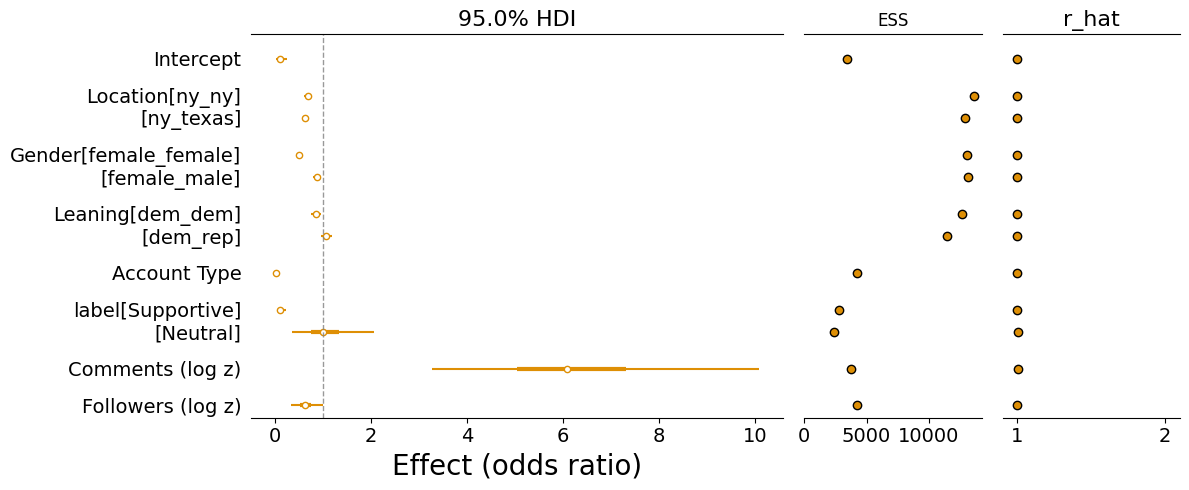

In [65]:
# model = bmb.Model(
#     "presence_no_rank ~ location + gender + ideology + type + label + comments_count_logz + followers_logz + (1|urlid) + (1|comment)",
#     data=concat_df,
#     family="bernoulli",
#     dropna=True,
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=1,
#     random_seed=42,
#     # weights = reg_df['weights'],
#     prob=0.95
# )

# var_names = ['Intercept', 'location', 'gender', 'ideology', 'type', 'label', 'comments_count_logz', 'followers_logz']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=True,
    ess=True,
    var_names=var_names,
    colors='C1'
)
TITLE_FS = 22
LABEL_FS = 20
TICK_FS  = 20
LEG_FS   = 20

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
axes[1].set_title("ESS")
new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)", fontsize=LABEL_FS)
plt.tight_layout()
# plt.show()
plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/comments_forestplot_combined.png', dpi=300)

Default computed for unspecified variable: comment, comments_count_logz, followers_logz, gender, ideology, label, type, urlid
Default computed for unspecified variable: comment, comments_count_logz, followers_logz, ideology, label, location, type, urlid
Default computed for unspecified variable: comment, comments_count_logz, followers_logz, gender, label, location, type, urlid
Default computed for unspecified variable: comment, comments_count_logz, followers_logz, gender, ideology, label, location, urlid
Default computed for unspecified variable: comment, comments_count_logz, followers_logz, gender, ideology, location, type, urlid
Default computed for conditional variable: comments_count_logz
Default computed for unspecified variable: comment, followers_logz, gender, ideology, label, location, type, urlid


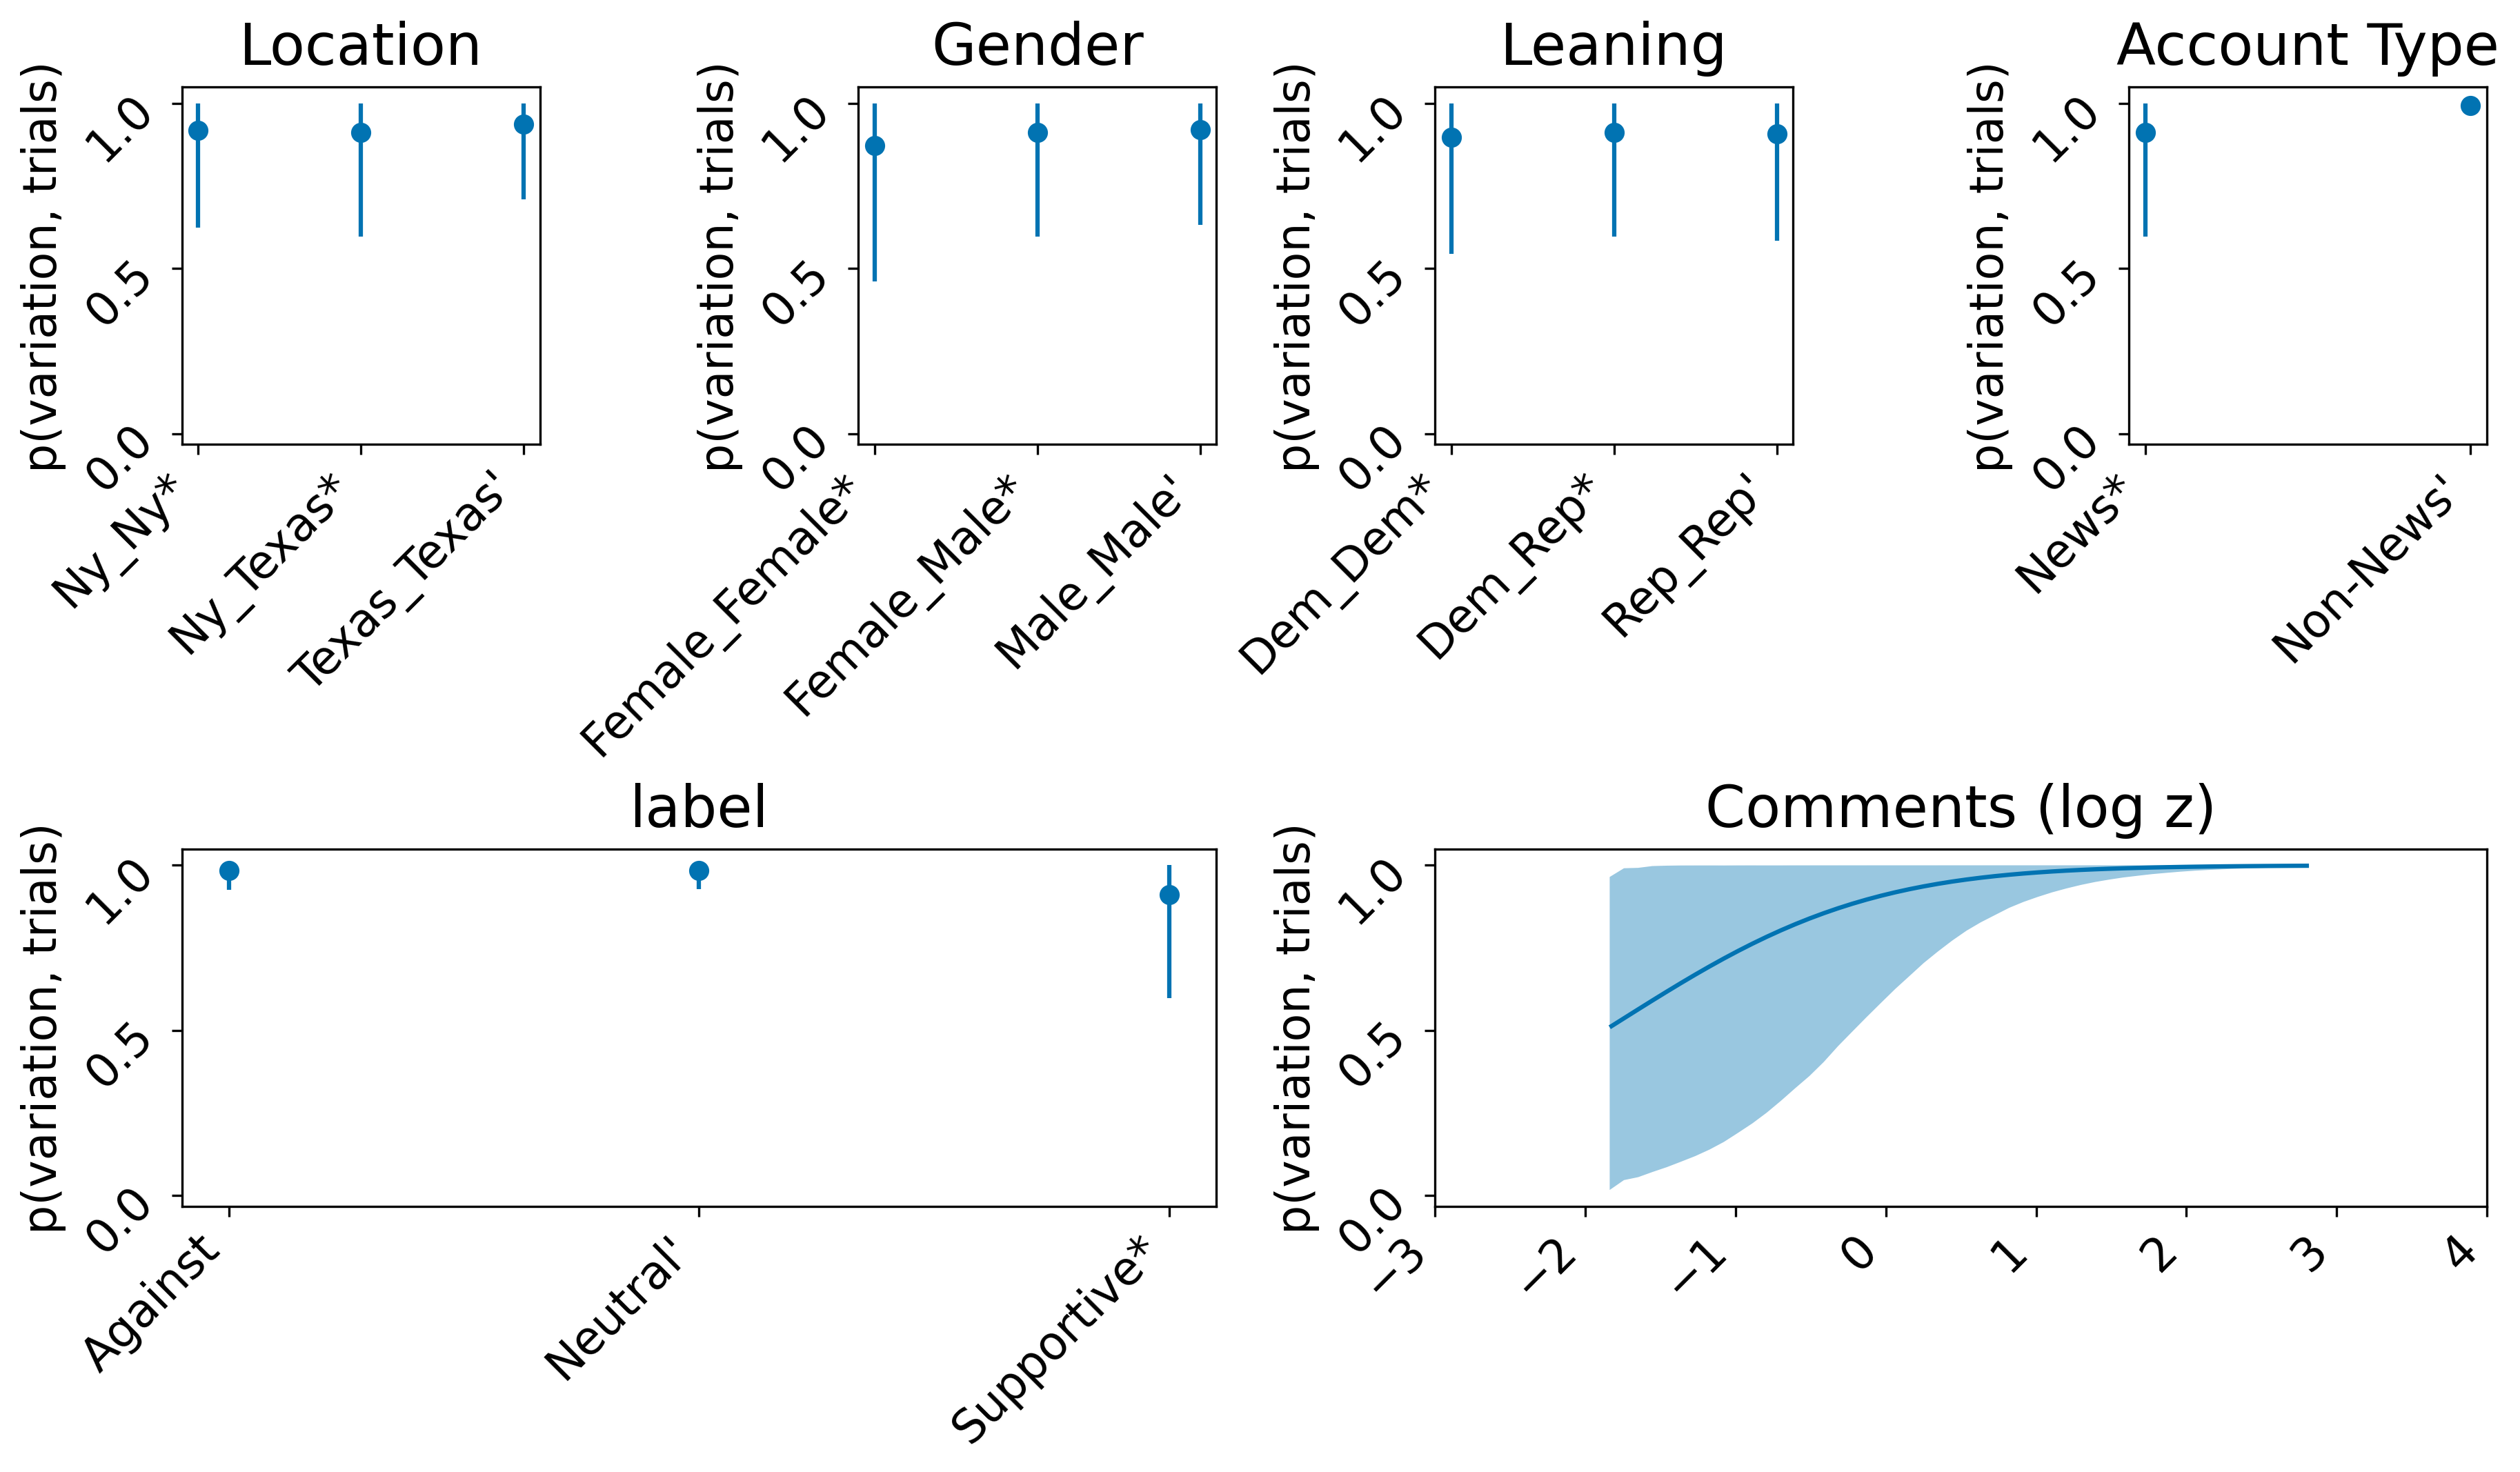

In [64]:
first_row = ["location", "gender", "ideology", "type", "label"]
second_row = ["comments_count_logz", "followers_logz"]
conditionals = first_row + second_row

TITLE_FS = 20
LABEL_FS = 16
TICK_FS  = 16
LEG_FS   = 16

data = model.data 

fig = plt.figure(figsize=(12, 7), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(2, 4)

axes = []
ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

for c in range(1, 4):
    axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

def conditional_spec(var):
    u = pd.Series(data[var]).dropna().unique().tolist()
    if len(u) <= 5:
        try:
            u_sorted = sorted(u, key=lambda x: float(x))
        except Exception:
            u_sorted = sorted(u, key=lambda x: str(x))
        return {var: u_sorted}, u_sorted
    return var, None

for ax, var in zip(axes, conditionals):
    cond, levels = conditional_spec(var)

    fig2, _ = bmb.interpret.plot_predictions(
        model, results,
        conditional=cond,
        prob=0.95,
        use_hdi=True,
        pps=False,
        legend=False,
        ax=ax,
    )
    if fig2 is not fig:
        plt.close(fig2)


    ax.set_title(edit_labels(var))
    ax.set_xlabel('')

    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
        leg.set_title(edit_labels(leg.get_title().get_text()))


    # Title
    ax.set_title(edit_labels(var), fontsize=TITLE_FS, pad=8)

    # Axis labels (keep x blank if you want, but set sizes anyway)
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABEL_FS)
    ax.set_ylabel(ax.get_ylabel(), fontsize=LABEL_FS)

    # Tick label sizes
    ax.tick_params(axis="both", which="major", labelsize=TICK_FS, labelrotation=45)

    # inside your loop, after plot_predictions(...)
    ticks = ax.get_xticks()
    ticklabels = [edit_labels(t.get_text()) for t in ax.get_xticklabels()]

    # apply your label editing function
    ax.set_xticks(ticks)
    ax.set_xticklabels([edit_labels(s) for s in ticklabels],
                    fontsize=TICK_FS, rotation=45, ha="right")

    # Legend text size (if any legend appears)
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title(edit_labels(leg.get_title().get_text()))
        leg.get_title().set_fontsize(LEG_FS)
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
            t.set_fontsize(LEG_FS)

    ax.set_ylabel('p(variation, trials)')


    if isinstance(cond, dict) and levels is not None:
        try:
            lv = np.array(levels, dtype=float)
            if lv.size == 2:
                ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
                ax.set_xticks(sorted(lv))
        except Exception:
            pass


axes[3].set_title("Account Type", fontsize=TITLE_FS, pad=8)

plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/comments_ppp_combined.png', dpi=300)

### Inter annotaor agreement

In [82]:
annotator_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')

In [83]:
annotator_data

,Url,Brahmani_Topics,Divya_Topics,Hamayoon_Topics,main_topic
0,https://www.instagram.com/msnownews/reel/DRYGz...,Political,Political,Political,Political
1,https://www.instagram.com/msnownews/reel/DRX71...,Political,Political,Political,Political
2,https://www.instagram.com/msnownews/reel/DRX7m...,Political,Political,Political,Political
3,https://www.instagram.com/morningjoe/reel/DRXy...,Non-Political,Non-Political,Non-Political,Non-Political
4,https://www.instagram.com/rosaflores/reel/DRXe...,Political,Political,Political,Political
...,...,...,...,...,...
95,https://www.instagram.com/wearebreitbart/reel/...,Political,Non-Political,Non-Political,Non-Political
96,https://www.instagram.com/wearebreitbart/p/DRW...,Political,Political,Political,Political
97,https://www.instagram.com/wearebreitbart/p/DRW...,Political,Political,Political,Political
98,https://www.instagram.com/wearebreitbart/reel/...,Political,Political,Political,Political


In [84]:
import pandas as pd
import numpy as np
import krippendorff


lab = annotator_data[annotation_columns].copy()

# Preserve missing values (do NOT use astype(str))
lab = lab.apply(lambda s: s.astype("string").str.strip().str.lower())

print("Unique labels (raw):", sorted(pd.unique(lab.values.ravel())))

mapping = {
    "political": 0,
    "non-political": 1,
}

lab.replace(mapping, inplace=True)

# Force numeric; anything unmapped becomes NaN
lab_num = lab_num.apply(pd.to_numeric, errors="coerce")

# Check for unmapped / missing
if lab_num.isna().any().any():
    bad_cells = lab.where(lab_num.isna())
    bad = sorted(pd.unique(bad_cells.values.ravel()))
    bad = [x for x in bad if x is not pd.NA and x == x]  # drop <NA>/nan
    raise ValueError(f"Unmapped or missing label(s) found: {bad}")

data = lab_num.to_numpy(dtype=float).T  # numeric (annotators, items)

alpha = krippendorff.alpha(
    reliability_data=data,
    level_of_measurement="nominal",
    value_domain=[0, 1],
)
print("Krippendorff's alpha:", float(alpha))


Unique labels (raw): ['non-political', 'political']
Krippendorff's alpha: 0.747511111111111


/var/folders/sh/fhrqk28n1bzd27x7z4p52c940000gn/T/ipykernel_32012/2269250542.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lab.replace(mapping, inplace=True)
/var/folders/sh/fhrqk28n1bzd27x7z4p52c940000gn/T/ipykernel_32012/2269250542.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lab.replace(mapping, inplace=True)
/var/folders/sh/fhrqk28n1bzd27x7z4p52c940000gn/T/ipykernel_32012/2269250542.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old beh

In [86]:
annotator_data[['Brahmani_Topics', 'Divya_Topics']].value_counts(), annotator_data[['Hamayoon_Topics', 'Divya_Topics']].value_counts(), annotator_data[['Brahmani_Topics', 'Hamayoon_Topics']].value_counts()

(Brahmani_Topics  Divya_Topics 
 Non-Political    Non-Political    46
 Political        Political        43
                  Non-Political    11
 Name: count, dtype: int64,
 Hamayoon_Topics  Divya_Topics 
 Non-Political    Non-Political    45
 Political        Political        41
                  Non-Political    12
 Non-Political    Political         2
 Name: count, dtype: int64,
 Brahmani_Topics  Hamayoon_Topics
 Political        Political          47
 Non-Political    Non-Political      40
 Political        Non-Political       7
 Non-Political    Political           6
 Name: count, dtype: int64)